In [1]:
from typing import Sequence
import numpy as np
import pandas as pd
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from sklearn import datasets
from sklearn.model_selection import train_test_split
from keras.metrics import Precision, Recall
from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:


buenos_rematesdf = pd.read_csv("/content/drive/MyDrive/SIS330/Proyecto/dataset/buenosremates.txt")
malos_rematesdf = pd.read_csv("/content/drive/MyDrive/SIS330/Proyecto/dataset/malosremates.txt")
print(len(buenos_rematesdf))
print(len(malos_rematesdf))
X = []
y = []
no_of_timesteps = 30

datasets = buenos_rematesdf.iloc[:,1:].values
#print(datasets)
n_samples = len(datasets)
print(n_samples)

for i in range(no_of_timesteps, n_samples):
    X.append(datasets[i-no_of_timesteps:i,:])
    y.append(1)

datasets = malos_rematesdf.iloc[:,1:].values
n_samples = len(datasets)
print(n_samples)

for i in range(no_of_timesteps, n_samples):
    X.append(datasets[i-no_of_timesteps:i,:])
    y.append(0)

X, y = np.array(X), np.array(y)
print(len(X),len(y))
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



1748
736
1748
736
2424 2424
(2424, 30, 34) (2424,)


In [10]:
print(len(X_train))
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

1939
(1939,)
(485, 30, 34)
(485,)


In [35]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation="sigmoid"))
model.compile(optimizer="adam",  metrics=["accuracy"],loss="binary_crossentropy")

model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test))
#model.save("/content/drive/MyDrive/SIS330/Proyecto/lstm-model2.h5")

Epoch 1/40
61/61 [==============================] - 17s 116ms/step - loss: 0.5363 - accuracy: 0.7200 - val_loss: 0.4811 - val_accuracy: 0.7031
Epoch 2/40
61/61 [==============================] - 5s 84ms/step - loss: 0.4444 - accuracy: 0.7746 - val_loss: 0.4212 - val_accuracy: 0.7856
Epoch 3/40
61/61 [==============================] - 6s 99ms/step - loss: 0.4066 - accuracy: 0.8169 - val_loss: 0.3920 - val_accuracy: 0.8000
Epoch 4/40
61/61 [==============================] - 5s 80ms/step - loss: 0.3917 - accuracy: 0.8169 - val_loss: 0.3543 - val_accuracy: 0.8247
Epoch 5/40
61/61 [==============================] - 6s 94ms/step - loss: 0.3695 - accuracy: 0.8324 - val_loss: 0.3615 - val_accuracy: 0.8103
Epoch 6/40
61/61 [==============================] - 5s 78ms/step - loss: 0.3490 - accuracy: 0.8319 - val_loss: 0.3356 - val_accuracy: 0.8371
Epoch 7/40
61/61 [==============================] - 4s 72ms/step - loss: 0.3388 - accuracy: 0.8345 - val_loss: 0.3105 - val_accuracy: 0.8433
Epoch 8/40


In [36]:
evaluation = model.evaluate(X_test, y_test)
print("Resultado de la evaluación:")
print("Loss:", evaluation[0])
print("Accuracy:", evaluation[1])
#print("Precision:", evaluation[2])
#print("Recall:", evaluation[3])

16/16 [==============================] - 0s 21ms/step - loss: 0.0030 - accuracy: 1.0000
Resultado de la evaluación:
Loss: 0.0030484020244330168
Accuracy: 1.0


In [37]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report

16/16 [==============================] - 1s 31ms/step
Matriz de Confusión:


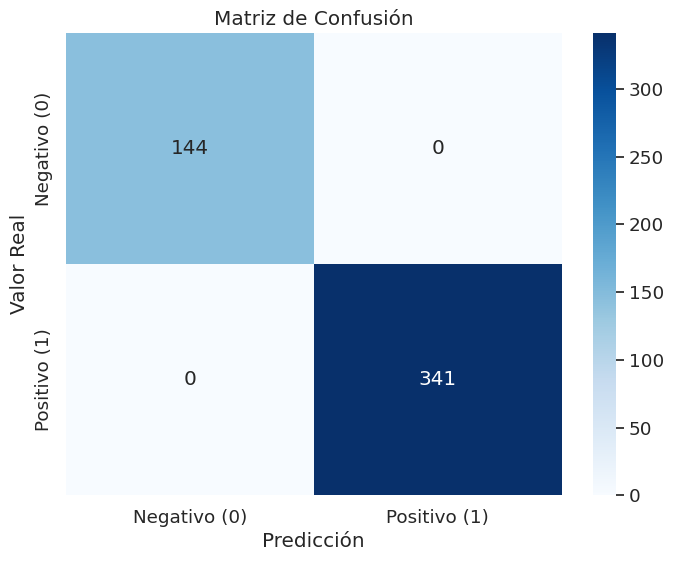


Métricas de Evaluación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       144
           1       1.00      1.00      1.00       341

    accuracy                           1.00       485
   macro avg       1.00      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485



In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
# Convertir las probabilidades continuas en clases binarias usando umbral de 0.5
y_pred_bin = (model.predict(X_test) > 0.5).astype("int32")
# Obtener la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_bin)
print("Matriz de Confusión:")
#print(conf_matrix)
# Definir etiquetas para los ejes
labels = ["Negativo (0)", "Positivo (1)"]

# Crear el heatmap de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Ajustar el tamaño de fuente para mejor legibilidad
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()
# Calcular otras métricas de evaluación
report = classification_report(y_test, y_pred_bin)

# Mostrar las métricas de evaluación
print("\nMétricas de Evaluación:")
print(report)

Tasa de Falsos Positivos (False Positive Rate): 0.0


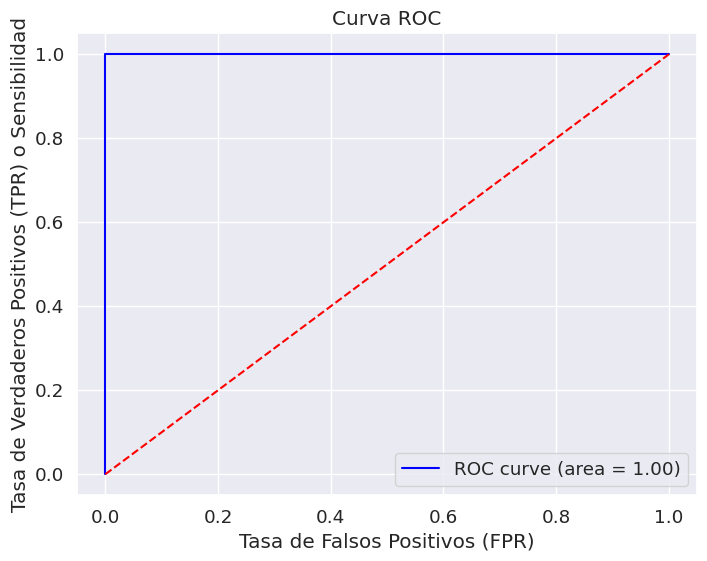

precision_score: 1.0
recall: 1.0
F-Score: 1.0


In [44]:
# Tasa de falsos positivos (False Positive Rate)
# Para calcular el FPR, necesitas tener los verdaderos negativos (True Negatives)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score, f1_score
conf_matrix = np.array(conf_matrix)
tn, fp, fn, tp = conf_matrix.ravel()
fpr = fp / (fp + tn)
print("Tasa de Falsos Positivos (False Positive Rate):", fpr)

# Curva ROC y área bajo la curva (AUC)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) o Sensibilidad')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

a=precision_score(y_test, y_pred_bin)
print("precision_score:",a)
recall= recall_score(y_test,y_pred_bin)
print("recall:",recall)
# F-Score
f_score = f1_score(y_test, y_pred_bin)
print("F-Score:", f_score)

16/16 [==============================] - 1s 32ms/step


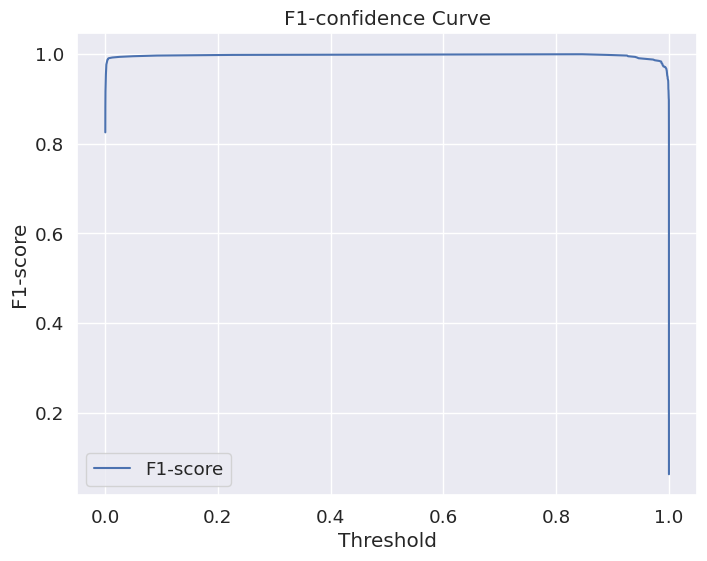

In [47]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Obtener las probabilidades de predicción
y_probs = model.predict(X_test)

# Calcular la curva precision-recall y el área bajo la curva (AUC)
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
auc_score = auc(recall, precision)

# Graficar la curva F1-confidence
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-score')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-confidence Curve')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
model.save("/content/drive/MyDrive/SIS330/Proyecto/lstm-model3.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
